In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 6** - Cake Recipe Optimisation (5D)

- Optimising a cake recipe using a black-box function with five ingredient inputs
    - E.g., example flour, sugar, eggs, butter and milk. 
    
- Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. 

- The total score is negative by design.

- **Goal** - bring the score as close to zero as possible.

**Input** - 5D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise (target: 0.0)  
**All-time best:** -0.128 at [0.593, 0.387, 0.658, 0.780, 0.074] (Week 5)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 6
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy')

# New data from Week 9 (Function 6)
X_w9_new_point = np.array([0.500522, 0.344002, 0.612748, 0.734912, 0.090373], dtype=np.float64)
Y_w9_new_point = np.array([-0.1618986945517302], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w9_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

Y_all = np.append(Y, Y_w9_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 6: ", X_unique)
print("Updated Outputs (Y) - Function 6: ", Y_updated)

Updated Inputs (X) - Function 6:  [[2.17353077e-02 4.28084240e-01 8.35939437e-01 4.89488659e-01
  5.11081735e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [1.26678917e-01 2.91470301e-01 6.45284767e-02 6.80514603e-01
  8.92819191e-01]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [2.58905574e-01 7.93677708e-01 6.42113905e-01 1.96673464e-01
  5.93103177e-01]
 [4.32165933e-01 7.15617813e-01 3.41819103e-01 7.04999881e-01
  6.14961845e-01]
 [4.39344264e-01 6.98923833e-01 4.26820222e-01 1.09476085e-01
  8.77888468e-01]
 [4.41233000e-01 9.98122000e-01 1.24500000e-03 5.56711000e-01
  3.21098000e-01]
 [4.61344000e-01 3.23423000e-01 8.03851000e-01 9.69268000e-01
  2.51090000e-02]
 [4.87084000e-01 1.49390000e-02 9.99330000e-01 9.73696000e-01
  9.98860000e-02]
 [4.97821000e-01 3.31178000e-01 6.38314000e-01 7.67495000e-01
  1.06570000e-02]
 [5.00

## **Output Analysis**

- **W8 Output:** -0.251
- **W9 Output:** -0.162

- **Comparison:** A genuine improvement from w8. 
    - The w9 recipe had $x_5 = 0.090$, very close to the w5 best value of 0.074. 
    - The x5 floor constraint is clearly working.
    
    - However, the all-time best of -0.128 remains unmatched. 
        - Comparing w9 input to the w5 best input, $x_4$ has dropped from 0.780 to 0.735 and $x_1$ from 0.593 to 0.501 both likely responsible for the remaining gap to the record.

- **Real-World Implication:** In recipe formulation, each ingredient contributes differently to the judging criteria. 
    - $x_4$ (butter) at the right level likely drives both the flavour and consistency scores significantly. 
    
    - Reducing it from 0.780 to 0.735 appears to have tipped the cake from nearly perfect to very good. 

- **Model Clues:** We are getting closer to -0.128 but the w5 best has not yet been matched.  

    - The remaining gap is primarily driven by $x_4$ being too low and $x_1$ being too low. 
    
- w10 must centre precisely on the w5 coordinates, keep the $x_5$ floor at 0.06, and use the tightest grid yet to avoid over-sampling nearby sub-optimal recipes.

## **Bayesian Optimisation** - Gaussian Process Regressor

- **Model:** Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson transformation.

- **Changes for w10 and Reasoning:**
    - I am keeping the same model architecture, it produced a genuine improvement in w9 and must not be reset.
    - I am tightening the focused grid std to 0.020 and re-centering strictly on the w5 all-time best. 
        - The W9 result at $x_4 = 0.735$ was too far from $x_4 = 0.780$ — std=0.03 (used in W9) was still too wide. 
        
    - Moving to `std=0.020` tightens the search around the target ingredients.

    - The $x_5$ floor constraint (minimum 0.06) is retained as it has successfully kept $x_5$ in the correct range for two consecutive weeks and should not be removed.

- **Theoretical Impact:** Tightening the std to 0.020 means $x_4$ will stay within [0.740, 0.820] preventing the drift from 0.780 down to 0.735 that occurred in w9. 
    - The GP's EI surface with a tighter std and low $\xi$ will place maximum probability mass precisely at the W5 ingredient profile.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

# Matern 2.5 + WhiteKernel — appropriate for the smooth but sensitive recipe landscape
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
model.fit(X_unique, Y_transformed)

Original Y:    [-1.35668211 -2.57116963 -1.74688209 -1.23378638 -1.20995524 -1.70255784
 -1.29424696 -2.0184254  -1.77750875 -0.51170708 -0.94759224 -0.25085626
 -0.16189869 -0.43136136 -1.14478485 -0.12781661 -0.53162631 -0.82923655
 -1.62283895 -0.60482914 -0.71426495 -1.67219994 -1.30911635 -1.53605771
 -0.93575656 -1.24704893 -2.15576776 -1.69434344 -1.91267714]
Transformed Y: [-0.24444218 -2.12108401 -0.85886125 -0.04822594 -0.01001406 -0.78967883
 -0.14493118 -1.27957381 -0.90657794  1.13712891  0.41442639  1.58258158
  1.73720468  1.27316488  0.09476303  1.79685421  1.10355247  0.60832667
 -0.66487218  0.98064819  0.79827595 -0.74220907 -0.16866255 -0.52843756
  0.43374505 -0.06946834 -1.490438   -0.7768412  -1.11635391]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function** - Expected Improvement (EI) with Physical Constraint Floor

- **Strategy:** Expected Improvement (EI) with $\xi = 0.01$ and a physical constraint floor on $x_5$.

- **Reasoning:** EI anchors the search to the current best of -0.128. 
    - With $\xi = 0.01$, the model will look for recipes that are meaningfully better than -0.128 — not just marginally different. 
    - The physical constraint on $x_5 \geq 0.06$ prevents the dry-recipe failure mode that caused regressions in earlier weeks.

- **Key Changes:**
    - Focused grid re-centred on W5 all-time best with std=0.020 (from 0.030 in W9).
    - $x_5$ hard floor at 0.06 maintained.
    - 90/10 focused-to-uniform split.

- **Intended Impact:** Match and surpass the w5 all-time best of -0.128 by precisely targeting the confirmed optimal ingredient profile.

In [4]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Re-center on W5 all-time best
w5_best = np.array([0.592613, 0.386959, 0.657734, 0.780318, 0.073699])

# 90% Focused, 10% Uniform
x_grid = np.random.normal(loc=w5_best, scale=0.020, size=(9000, 5))
x_uniform_part = np.random.uniform(0, 1, size=(1000, 5))
x_grid = np.vstack([x_grid, x_uniform_part])

# Physical constraint: x5 must stay above 0.06 — recipes fail below this threshold
x_grid[:, 4] = np.maximum(x_grid[:, 4], 0.06)
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)
next_query = x_grid[np.argmax(ei_values)]

print(f'W5 best coordinates: {w5_best}')
print(f'Strategic Week 10 Query (Function 6): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}')

W5 best coordinates: [0.592613 0.386959 0.657734 0.780318 0.073699]
Strategic Week 10 Query (Function 6): 0.164117-0.215391-0.479099-0.726337-0.060000


## **Visualisation**

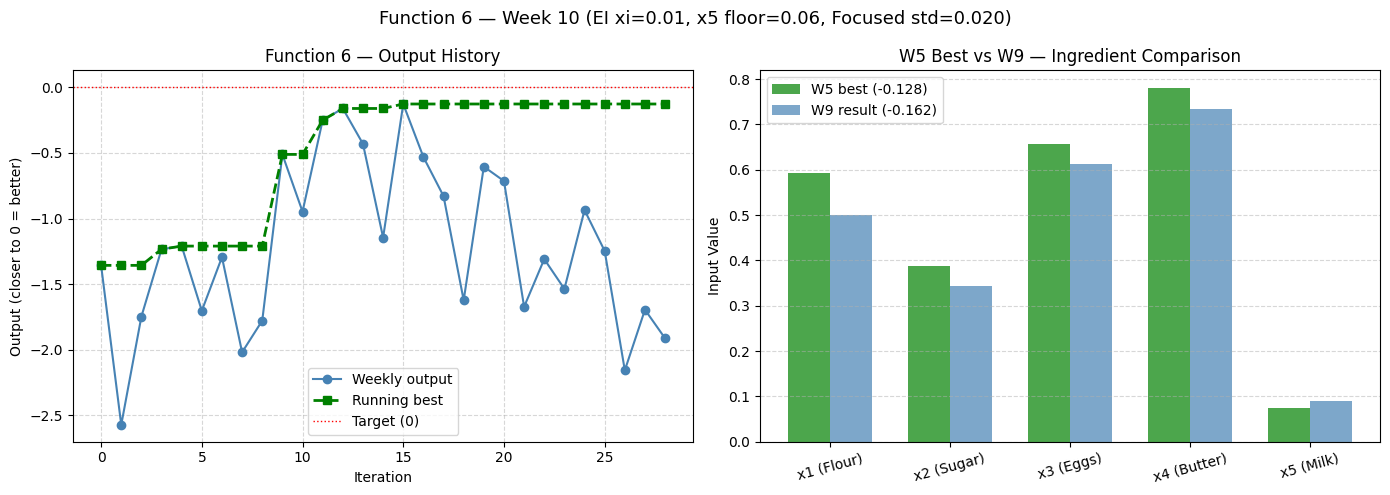

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Target (0)')
axes[0].set_title('Function 6 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output (closer to 0 = better)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

ingredient_labels = ['x1 (Flour)', 'x2 (Sugar)', 'x3 (Eggs)', 'x4 (Butter)', 'x5 (Milk)']
x_pos = np.arange(len(ingredient_labels))
width = 0.35
axes[1].bar(x_pos - width/2, w5_best, width, label='W5 best (-0.128)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w9_new_point, width, label='W9 result (-0.162)', color='steelblue', alpha=0.7)
axes[1].set_title('W5 Best vs W9 — Ingredient Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ingredient_labels, rotation=15)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 6 — Week 10 (EI xi=0.01, x5 floor=0.06, Focused std=0.020)', fontsize=13)
plt.tight_layout()
plt.show()